In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# =============================================================================
# STEP 1: UNDERSTANDING THE DATASET
# =============================================================================

import pandas as pd

# UCI Chronic Kidney Disease dataset (Rubini, Soundarapandian & Eswaran, 2015,
# UCI ML Repository, DOI 10.24432/C5G020). 400 patients seen at a hospital in
# Tamil Nadu, India, over ~2 months. See data/DATA_SOURCES.md.
df = pd.read_csv("../../data/raw/ckd.csv")   # Update path if needed

# Drop the row-id column — it's not a feature
df = df.drop(columns=["id"])


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


print("\n" + "=" * 70)
print("FEATURE NAMES")
print("=" * 70)
print(df.columns.tolist())


print("\n" + "=" * 70)
print("FIRST FIVE RECORDS")
print("=" * 70)
display(df.head())


print("\n" + "=" * 70)
print("LAST FIVE RECORDS")
print("=" * 70)
display(df.tail())


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)
df.info()


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
display(df.dtypes.to_frame(name="Data Type"))

print("\nNOTE: pcv, wc, and rc show up as object (text) dtype here, not")
print("numeric — even though they're numeric lab values (packed cell volume,")
print("white cell count, red cell count). This is a known quirk of this exact")
print("UCI file: stray whitespace in the raw source breaks pandas' numeric")
print("parsing. Fixed explicitly in Step 1b below rather than silently.")


print("\n" + "=" * 70)
print("MISSING VALUES OVERVIEW")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum()/len(df))*100
})

display(missing_summary)


print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)
print(f"Total Duplicate Rows : {df.duplicated().sum()}")


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 70)
display(df.describe().T)


print("\n" + "=" * 70)
print("SUMMARY STATISTICS - CATEGORICAL FEATURES")
print("=" * 70)

categorical_cols = df.select_dtypes(include="object").columns

if len(categorical_cols) > 0:
    display(df.describe(include="object").T)
else:
    print("No categorical features found")


print("\n" + "=" * 70)
print("MEMORY USAGE")
print("=" * 70)

memory_usage = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage : {memory_usage:.2f} MB")

DATASET SHAPE
Rows    : 400
Columns : 25

FEATURE NAMES
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

FIRST FIVE RECORDS


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd



LAST FIVE RECORDS


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,131.0,...,53,6800,6.1,no,no,no,good,no,no,notckd



DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    str    
 6   pc              335 non-null    str    
 7   pcc             396 non-null    str    
 8   ba              396 non-null    str    
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    str    
 16  wc              295 non-null    str    
 17  rc              270 non-n

...


DUPLICATE RECORDS
Total Duplicate Rows : 0

SUMMARY STATISTICS - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000



SUMMARY STATISTICS - CATEGORICAL FEATURES


,count,unique,top,freq
rbc,248,2,normal,201
pc,335,2,normal,259
pcc,396,2,notpresent,354
ba,396,2,notpresent,374
pcv,330,44,52,21
wc,295,92,9800,11
rc,270,49,5.2,18
htn,398,2,no,251
dm,398,5,no,258
cad,398,3,no,362



MEMORY USAGE
Memory Usage : 0.31 MB


In [3]:
# =============================================================================
# STEP 1b: DATA TYPE & LABEL CLEANUP (CKD-specific — not needed for the other
# two datasets, but required here before any of the later steps will work)
# =============================================================================

print("=" * 70)
print("BEFORE CLEANUP")
print("=" * 70)
print("classification unique values:", df["classification"].unique().tolist())
print("pcv dtype:", df["pcv"].dtype, "| wc dtype:", df["wc"].dtype, "| rc dtype:", df["rc"].dtype)


# 1. Strip stray whitespace/tabs from every text column (this dataset has a
#    documented "ckd\t" vs "ckd" inconsistency in the label column caused by
#    a trailing tab character in the original source file).
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({"nan": np.nan, "?": np.nan})

# 2. pcv / wc / rc are genuinely numeric lab values — convert them, coercing
#    anything unparseable (leftover artifacts) to NaN rather than dropping rows.
for col in ["pcv", "wc", "rc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Encode the target as 0/1 for correlation analysis later, while keeping
#    the original text label too.
df["target"] = df["classification"].map({"ckd": 1, "notckd": 0})


print("\n" + "=" * 70)
print("AFTER CLEANUP")
print("=" * 70)
print("classification unique values:", df["classification"].unique().tolist())
print("pcv dtype:", df["pcv"].dtype, "| wc dtype:", df["wc"].dtype, "| rc dtype:", df["rc"].dtype)
print("target value counts:", df["target"].value_counts().to_dict())

BEFORE CLEANUP
classification unique values: ['ckd', 'ckd\t', 'notckd']
pcv dtype: str | wc dtype: str | rc dtype: str

AFTER CLEANUP
classification unique values: ['ckd', 'notckd']
pcv dtype: float64 | wc dtype: float64 | rc dtype: float64
target value counts: {1: 250, 0: 150}


MISSING VALUE COUNT


,Missing Values
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44



MISSING VALUE PERCENTAGE


,Missing Count,Missing Percentage (%)
rbc,152,38.00
rc,131,32.75
wc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75



FEATURES WITH MISSING VALUES


,Missing Count,Missing Percentage (%)
rbc,152,38.00
rc,131,32.75
wc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75



MISSING VALUE VISUALIZATION


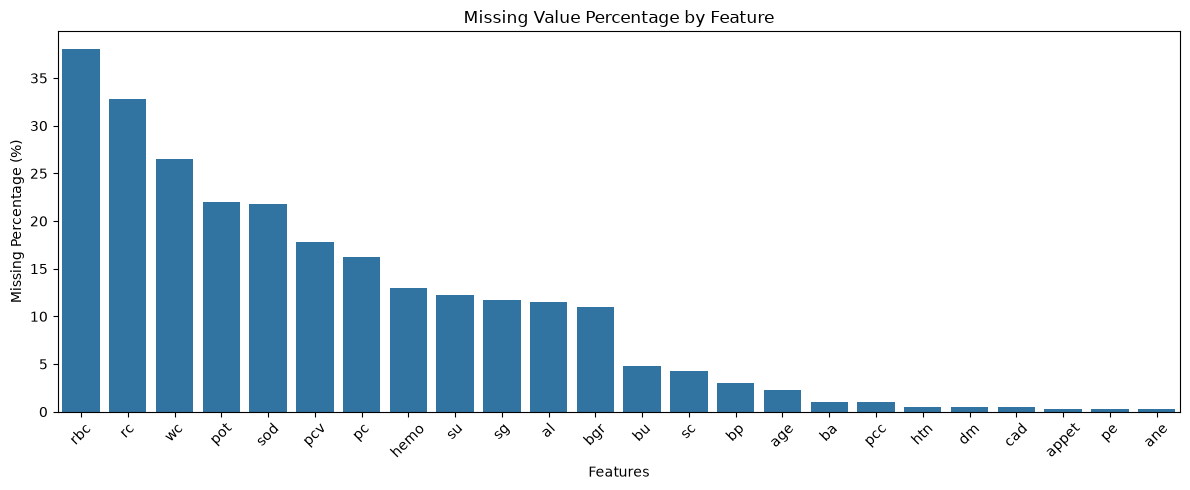


TOTAL MISSING VALUES
Total Missing Values : 1012
Overall Missing Rate : 9.73%

This is real, substantial missingness (unlike breast cancer's 0% and
diabetes's near-0%) — rbc alone is missing for 38% of patients.
Decide and document the imputation strategy in docs/methodology.md
before 02_ckd_doda.ipynb; do not default to silent mean-fill given
how skewed lab values like sc (serum creatinine) are.


In [4]:
# =============================================================================
# STEP 2: MISSING VALUE ANALYSIS
# =============================================================================


print("=" * 70)
print("MISSING VALUE COUNT")
print("=" * 70)

missing_count = df.isnull().sum()

display(
    missing_count.to_frame(name="Missing Values")
)


print("\n" + "=" * 70)
print("MISSING VALUE PERCENTAGE")
print("=" * 70)

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percentage.round(2)
}).sort_values("Missing Percentage (%)", ascending=False)

display(missing_summary)


print("\n" + "=" * 70)
print("FEATURES WITH MISSING VALUES")
print("=" * 70)

missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_features) > 0:
    display(missing_features)
else:
    print("No missing values found in the dataset")


print("\n" + "=" * 70)
print("MISSING VALUE VISUALIZATION")
print("=" * 70)

missing_plot = missing_features

if len(missing_plot) > 0:
    plt.figure(figsize=(12,5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing Percentage (%)"]
    )

    plt.xticks(rotation=45)
    plt.ylabel("Missing Percentage (%)")
    plt.xlabel("Features")
    plt.title("Missing Value Percentage by Feature")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values to visualize")


print("\n" + "=" * 70)
print("TOTAL MISSING VALUES")
print("=" * 70)

total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]

print(f"Total Missing Values : {total_missing}")
print(f"Overall Missing Rate : {total_missing/total_cells*100:.2f}%")
print()
print("This is real, substantial missingness (unlike breast cancer's 0% and")
print("diabetes\'s near-0%) — rbc alone is missing for 38% of patients.")
print("Decide and document the imputation strategy in docs/methodology.md")
print("before 02_ckd_doda.ipynb; do not default to silent mean-fill given")
print("how skewed lab values like sc (serum creatinine) are.")

In [5]:
# =============================================================================
# STEP 3: DUPLICATE ANALYSIS
# =============================================================================


print("=" * 70)
print("TOTAL DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")


print("\n" + "=" * 70)
print("DUPLICATE PERCENTAGE")
print("=" * 70)

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")


print("\n" + "=" * 70)
print("DUPLICATE RECORDS PREVIEW")
print("=" * 70)

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    display(duplicate_rows.head())
else:
    print("No duplicate records found")


print("\n" + "=" * 70)
print("DATASET SIZE BEFORE DUPLICATE REMOVAL")
print("=" * 70)

print(f"Rows Before Removal : {df.shape[0]}")


print("\n" + "=" * 70)
print("DUPLICATE REMOVAL")
print("=" * 70)

df_clean = df.drop_duplicates()

print(f"Rows After Removal : {df_clean.shape[0]}")


print("\n" + "=" * 70)
print("ROWS REMOVED")
print("=" * 70)

rows_removed = df.shape[0] - df_clean.shape[0]

print(f"Total Rows Removed : {rows_removed}")

TOTAL DUPLICATE RECORDS
Duplicate Rows : 0

DUPLICATE PERCENTAGE
Duplicate Percentage : 0.00%

DUPLICATE RECORDS PREVIEW
No duplicate records found

DATASET SIZE BEFORE DUPLICATE REMOVAL
Rows Before Removal : 400

DUPLICATE REMOVAL
Rows After Removal : 400

ROWS REMOVED
Total Rows Removed : 0



DUPLICATE RECORD VISUALIZATION


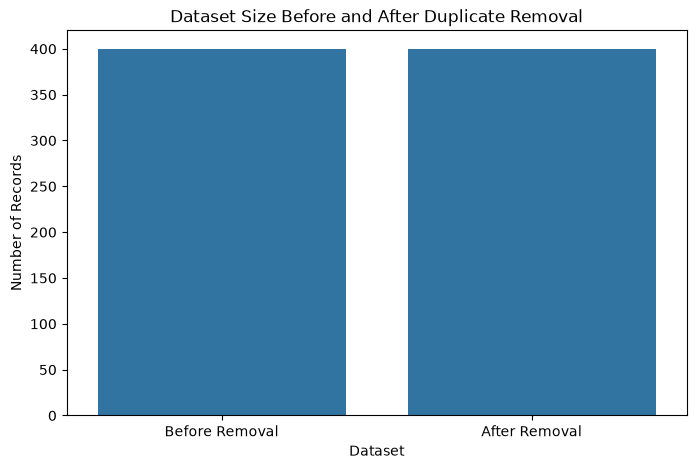


DUPLICATE VS UNIQUE RECORD DISTRIBUTION


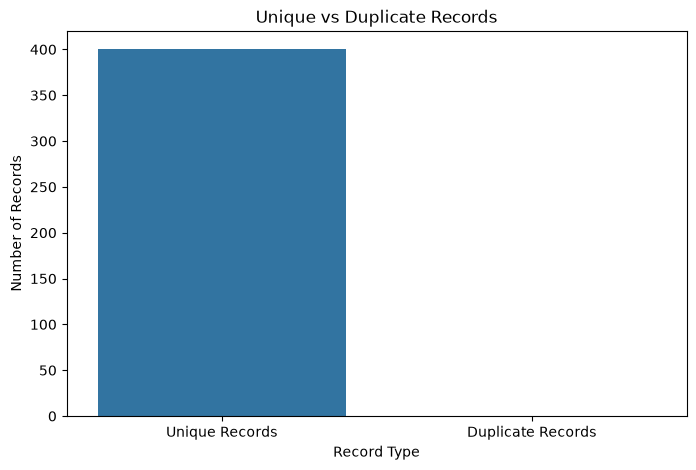

In [6]:
print("\n" + "=" * 70)
print("DUPLICATE RECORD VISUALIZATION")
print("=" * 70)


duplicate_comparison = pd.DataFrame({
    "Dataset": ["Before Removal", "After Removal"],
    "Number of Records": [
        df.shape[0],
        df_clean.shape[0]
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_comparison,
    x="Dataset",
    y="Number of Records"
)

plt.title("Dataset Size Before and After Duplicate Removal")
plt.ylabel("Number of Records")
plt.xlabel("Dataset")
plt.show()


print("\n" + "=" * 70)
print("DUPLICATE VS UNIQUE RECORD DISTRIBUTION")
print("=" * 70)


duplicate_distribution = pd.DataFrame({
    "Record Type": [
        "Unique Records",
        "Duplicate Records"
    ],
    "Count": [
        df_clean.shape[0],
        duplicate_count
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=duplicate_distribution,
    x="Record Type",
    y="Count"
)

plt.title("Unique vs Duplicate Records")
plt.ylabel("Number of Records")
plt.xlabel("Record Type")
plt.show()

NUMERICAL FEATURES
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

NUMERICAL FEATURE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000



NUMERICAL FEATURE DISTRIBUTION


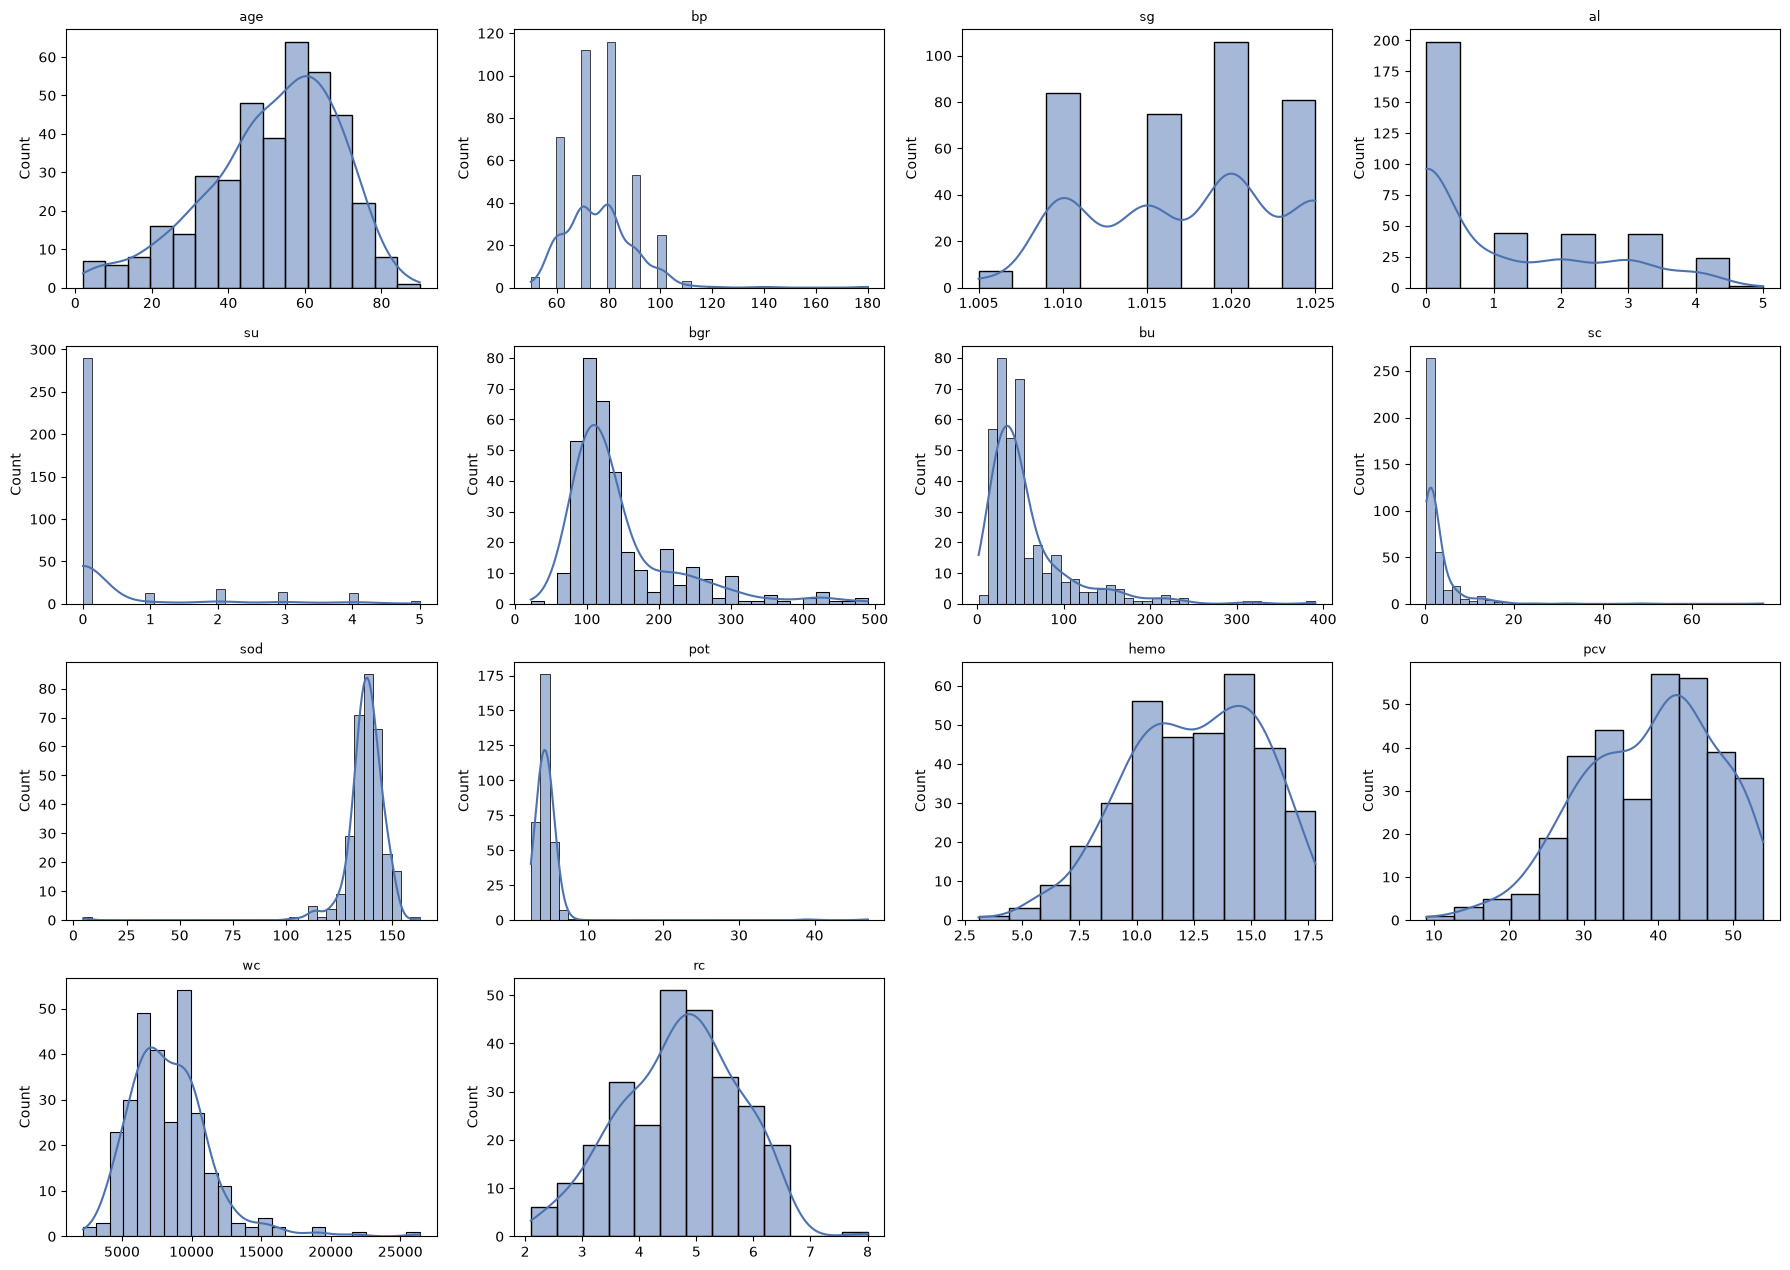

In [7]:
# =============================================================================
# STEP 4: UNIVARIATE ANALYSIS
# =============================================================================


df = df_clean.copy()


print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)


numerical_features = df.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

numerical_features = [f for f in numerical_features if f != "target"]

print(numerical_features)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE STATISTICS")
print("=" * 70)

display(df[numerical_features].describe().T)



print("\n" + "=" * 70)
print("NUMERICAL FEATURE DISTRIBUTION")
print("=" * 70)

n_features = len(numerical_features)
cols = 4
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*3.2))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# CATEGORICAL FEATURE ANALYSIS
# =============================================================================


print("\n" + "=" * 70)
print("CATEGORICAL / BINARY FEATURES")
print("=" * 70)


categorical_features = [
    "rbc", "pc", "pcc", "ba",
    "htn", "dm", "cad", "appet", "pe", "ane"
]

# Keep only columns present in dataset
categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

print(categorical_features)



print("\n" + "=" * 70)
print("CATEGORICAL FEATURE DISTRIBUTION")
print("=" * 70)


for feature in categorical_features:
    display(
        df[feature]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )


CATEGORICAL / BINARY FEATURES
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

CATEGORICAL FEATURE DISTRIBUTION


,Count
rbc,
normal,201
NaN,152
abnormal,47


,Count
pc,
normal,259
abnormal,76
NaN,65


,Count
pcc,
notpresent,354
present,42
NaN,4


,Count
ba,
notpresent,374
present,22
NaN,4


...

,Count
dm,
no,261
yes,137
NaN,2


,Count
cad,
no,364
yes,34
NaN,2


,Count
appet,
good,317
poor,82
NaN,1


,Count
pe,
no,323
yes,76
NaN,1


,Count
ane,
no,339
yes,60
NaN,1


In [9]:
# =============================================================================
# STEP 5: OUTLIER ANALYSIS
# =============================================================================


print("=" * 70)
print("NUMERICAL FEATURES FOR OUTLIER ANALYSIS")
print("=" * 70)

print(numerical_features)


print("\n" + "=" * 70)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 70)


outlier_summary = []


for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR


    outliers = df[
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ]


    outlier_count = len(outliers)
    non_null = df[feature].notna().sum()
    outlier_percentage = (outlier_count / non_null * 100) if non_null > 0 else 0


    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": round(lower_limit,2),
        "Upper Bound": round(upper_limit,2),
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": round(outlier_percentage,2)
    })


outlier_df = pd.DataFrame(outlier_summary).sort_values(
    "Outlier Percentage (%)", ascending=False
).reset_index(drop=True)

display(outlier_df)

print("\nHigh outlier rates here (e.g. su, sc, bu) are clinically expected,")
print("not necessarily data errors — CKD patients genuinely have extreme lab")
print("values compared to healthy patients. Inspect before capping/removing")
print("anything; an \'outlier\' here may be exactly the signal that matters.")

NUMERICAL FEATURES FOR OUTLIER ANALYSIS
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

OUTLIER DETECTION USING IQR METHOD


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,su,0.00,0.00,61,17.38
1,sc,-1.95,5.65,51,13.32
2,bu,-31.50,124.50,38,9.97
3,bgr,3.00,259.00,34,9.55
4,bp,55.00,95.00,36,9.28
5,sod,124.50,152.50,16,5.11
6,wc,1550.00,14750.00,10,3.40
7,age,8.25,98.25,10,2.56
8,pot,2.15,6.55,4,1.28
9,rc,1.65,7.65,1,0.37



High outlier rates here (e.g. su, sc, bu) are clinically expected,
not necessarily data errors — CKD patients genuinely have extreme lab
values compared to healthy patients. Inspect before capping/removing
anything; an 'outlier' here may be exactly the signal that matters.



BOXPLOT VISUALIZATION


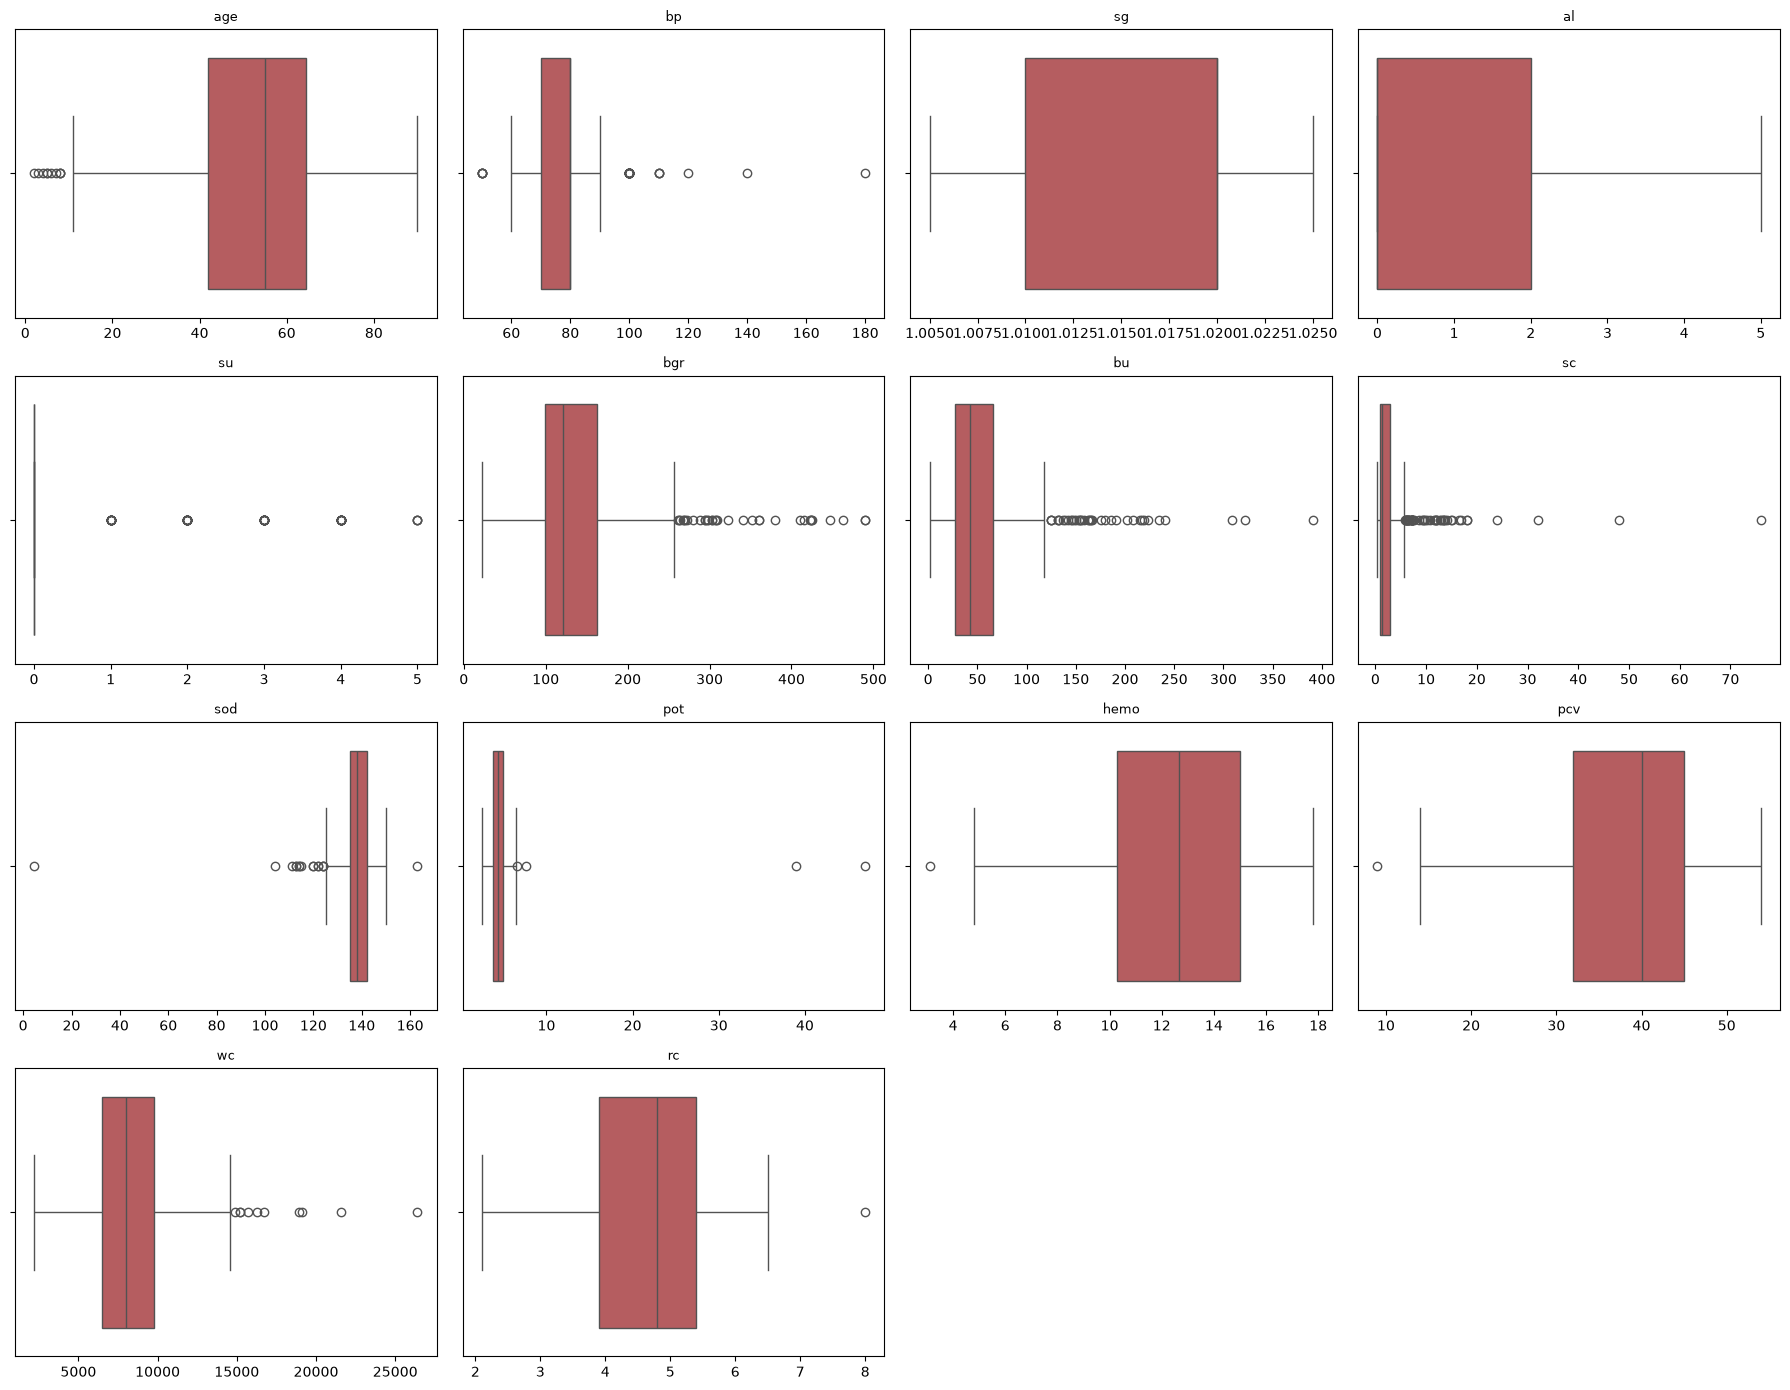

In [10]:
print("\n" + "=" * 70)
print("BOXPLOT VISUALIZATION")
print("=" * 70)


n_features = len(numerical_features)
cols = 4
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*3.5))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color="#C44E52")
    axes[i].set_title(f"{feature}", fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()


OUTLIER PERCENTAGE VISUALIZATION


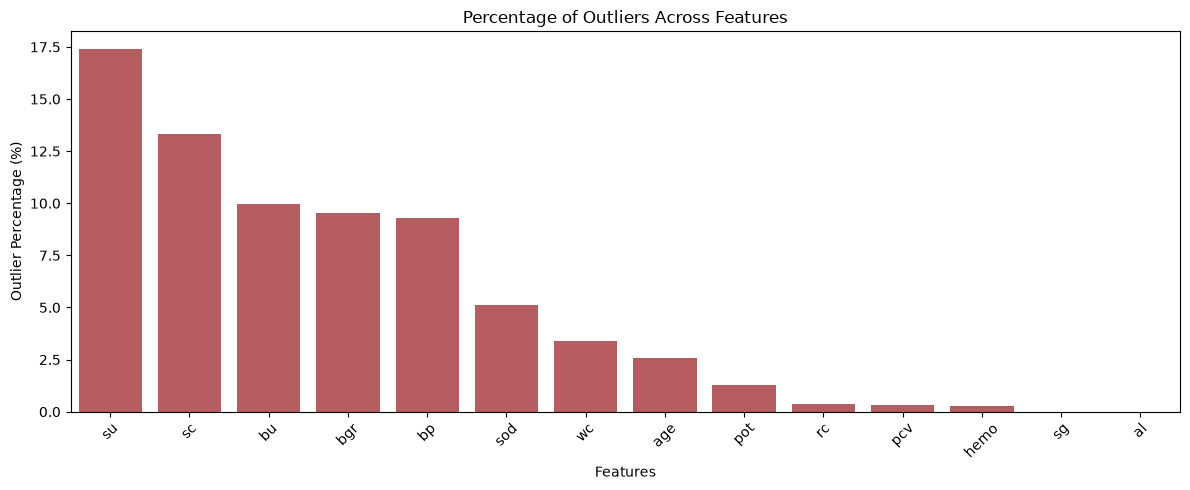

In [11]:
print("\n" + "=" * 70)
print("OUTLIER PERCENTAGE VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(12,5))

sns.barplot(
    data=outlier_df,
    x="Feature",
    y="Outlier Percentage (%)",
    color="#C44E52"
)

plt.title("Percentage of Outliers Across Features")
plt.xlabel("Features")
plt.ylabel("Outlier Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TARGET VARIABLE DISTRIBUTION
target
1    250
0    150
Name: count, dtype: int64

CLASS DISTRIBUTION PERCENTAGE


,Class Count,Percentage (%)
target,,
1,250,62.5
0,150,37.5



CLASS LABEL MAPPING
Class 1 (ckd) : 250 samples
Class 0 (notckd) : 150 samples

CLASS DISTRIBUTION VISUALIZATION


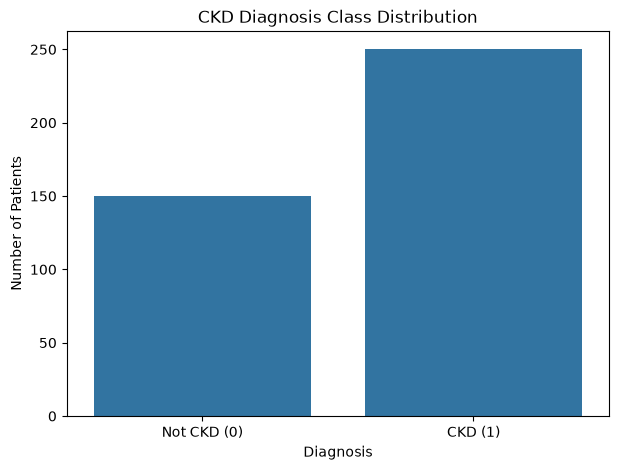


CLASS BALANCE RATIO
Minority/Majority Class Ratio : 0.600
Similar mild imbalance to breast cancer (~3:5) — use
class_weight='balanced' in the DODA modeling notebook as a baseline,
and watch specifically for the Random Forest accuracy/recall trade-off
flagged in docs/known_issues.md given how small this dataset is (n=400)
compared to diabetes (n≈230K) — instability is more likely here.


In [12]:
# =============================================================================
# STEP 6: CLASS DISTRIBUTION ANALYSIS
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 70)


target_column = "target"   # 0 = notckd, 1 = ckd


print(df[target_column].value_counts())



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PERCENTAGE")
print("=" * 70)

class_distribution = pd.DataFrame({
    "Class Count": df[target_column].value_counts(),
    "Percentage (%)": (
        df[target_column]
        .value_counts(normalize=True) * 100
    ).round(2)
})


display(class_distribution)



print("\n" + "=" * 70)
print("CLASS LABEL MAPPING")
print("=" * 70)


label_names = {0: "notckd", 1: "ckd"}
for label, count in df[target_column].value_counts().items():
    print(f"Class {label} ({label_names[label]}) : {count} samples")



print("\n" + "=" * 70)
print("CLASS DISTRIBUTION VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=target_column
)

plt.xticks([0,1], ["Not CKD (0)", "CKD (1)"])
plt.title("CKD Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()



print("\n" + "=" * 70)
print("CLASS BALANCE RATIO")
print("=" * 70)


class_ratio = (
    df[target_column]
    .value_counts()
    .min()
    /
    df[target_column]
    .value_counts()
    .max()
)


print(f"Minority/Majority Class Ratio : {class_ratio:.3f}")
print("Similar mild imbalance to breast cancer (~3:5) — use")
print("class_weight=\'balanced\' in the DODA modeling notebook as a baseline,")
print("and watch specifically for the Random Forest accuracy/recall trade-off")
print("flagged in docs/known_issues.md given how small this dataset is (n=400)")
print("compared to diabetes (n≈230K) — instability is more likely here.")

In [13]:
# =============================================================================
# STEP 7: CORRELATION ANALYSIS
# =============================================================================


print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)


correlation_matrix = df[numerical_features + [target_column]].corr()


display(correlation_matrix.round(2))

CORRELATION MATRIX


,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,target
age,1.00,0.16,-0.19,0.12,0.22,0.24,0.20,0.13,-0.10,0.06,-0.19,-0.24,0.12,-0.27,0.23
bp,0.16,1.00,-0.22,0.16,0.22,0.16,0.19,0.15,-0.12,0.08,-0.31,-0.33,0.03,-0.26,0.29
sg,-0.19,-0.22,1.00,-0.47,-0.30,-0.37,-0.31,-0.36,0.41,-0.07,0.60,0.60,-0.24,0.58,-0.73
al,0.12,0.16,-0.47,1.00,0.27,0.38,0.45,0.40,-0.46,0.13,-0.63,-0.61,0.23,-0.57,0.63
su,0.22,0.22,-0.30,0.27,1.00,0.72,0.17,0.22,-0.13,0.22,-0.22,-0.24,0.18,-0.24,0.34
bgr,0.24,0.16,-0.37,0.38,0.72,1.00,0.14,0.11,-0.27,0.07,-0.31,-0.30,0.15,-0.28,0.42
bu,0.20,0.19,-0.31,0.45,0.17,0.14,1.00,0.59,-0.32,0.36,-0.61,-0.61,0.05,-0.58,0.38
sc,0.13,0.15,-0.36,0.40,0.22,0.11,0.59,1.00,-0.69,0.33,-0.40,-0.40,-0.01,-0.40,0.30
sod,-0.10,-0.12,0.41,-0.46,-0.13,-0.27,-0.32,-0.69,1.00,0.10,0.37,0.38,0.01,0.34,-0.38
pot,0.06,0.08,-0.07,0.13,0.22,0.07,0.36,0.33,0.10,1.00,-0.13,-0.16,-0.11,-0.16,0.08



CORRELATION HEATMAP


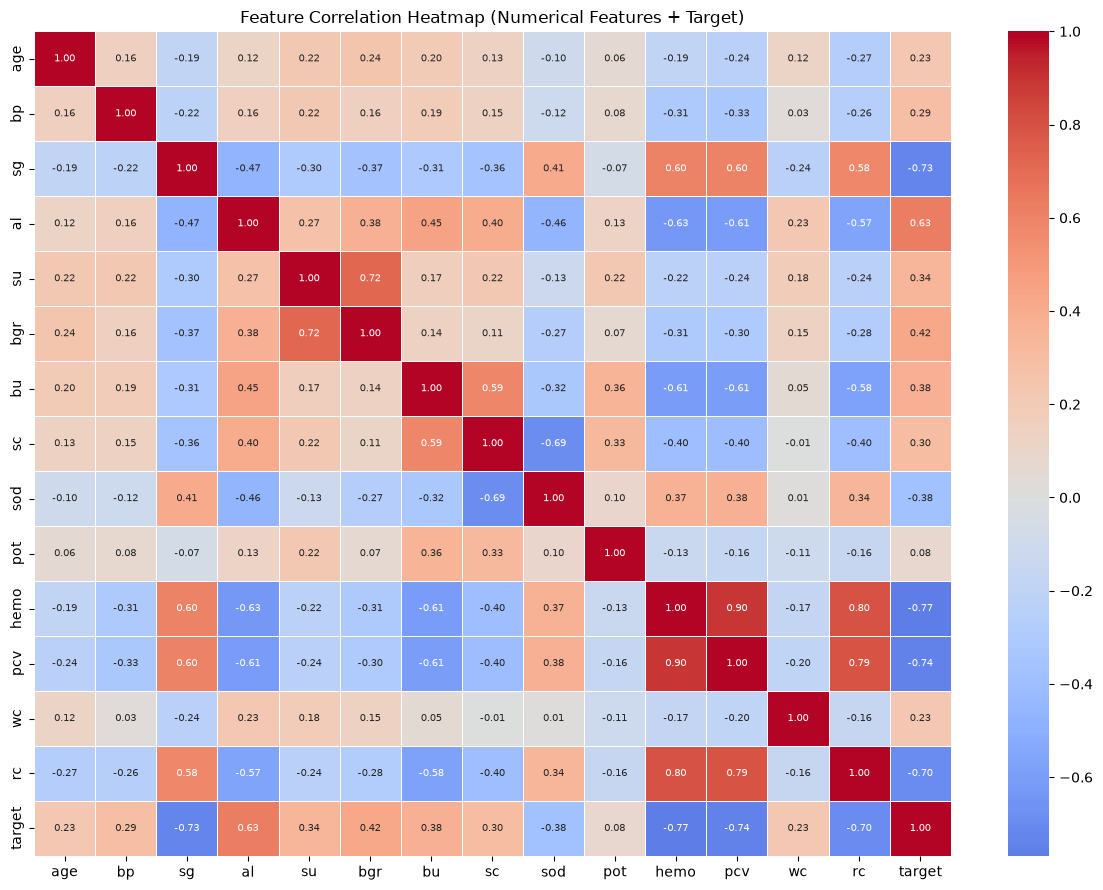


Note: hemoglobin, packed cell volume, specific gravity, and red
cell count are strongly NEGATIVELY correlated with CKD (i.e. lower
values -> more likely CKD) — consistent with CKD-associated anemia
and reduced urine concentrating ability. Albumin, blood glucose,
blood urea, and serum creatinine are POSITIVELY correlated, consistent
with reduced kidney filtration. This is a useful cross-check for the
clinical weight dictionary in config/clinical_weights/ckd.yaml.


In [14]:
print("\n" + "=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)


plt.figure(figsize=(12,9))


sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size":7}
)


plt.title("Feature Correlation Heatmap (Numerical Features + Target)")
plt.tight_layout()
plt.show()

print("\nNote: hemoglobin, packed cell volume, specific gravity, and red")
print("cell count are strongly NEGATIVELY correlated with CKD (i.e. lower")
print("values -> more likely CKD) — consistent with CKD-associated anemia")
print("and reduced urine concentrating ability. Albumin, blood glucose,")
print("blood urea, and serum creatinine are POSITIVELY correlated, consistent")
print("with reduced kidney filtration. This is a useful cross-check for the")
print("clinical weight dictionary in config/clinical_weights/ckd.yaml.")

In [15]:
# =============================================================================
# STEP 8: RELATIONSHIP WITH TARGET VARIABLE
# =============================================================================


print("=" * 70)
print("TARGET VARIABLE RELATIONSHIP ANALYSIS")
print("=" * 70)


print("Numerical Features:")
print(numerical_features)


print("\nCategorical/Binary Features:")
print(categorical_features)

TARGET VARIABLE RELATIONSHIP ANALYSIS
Numerical Features:
['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

Categorical/Binary Features:
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [16]:
print("\n" + "=" * 70)
print("TOP 6 NUMERICAL FEATURES BY CKD STATUS")
print("=" * 70)

top_features = (
    correlation_matrix[target_column]
    .drop(target_column)
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

print("Top 6 features:", top_features)

for feature in top_features:
    print("\n")
    print("-"*60)
    print(feature)
    print("-"*60)
    display(
        df.groupby(target_column)[feature]
        .describe()
    )


TOP 6 NUMERICAL FEATURES BY CKD STATUS
Top 6 features: ['hemo', 'pcv', 'sg', 'rc', 'al', 'bgr']


------------------------------------------------------------
hemo
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,144.0,15.188194,1.277536,13.0,14.100,15.0,16.200,17.8
1,204.0,10.647549,2.185790,3.1,9.475,10.9,12.025,16.1




------------------------------------------------------------
pcv
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,146.0,46.335616,4.134426,40.0,43.0,46.0,50.0,54.0
1,183.0,32.939891,7.208945,9.0,28.5,33.0,37.0,52.0




------------------------------------------------------------
sg
------------------------------------------------------------


...

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,143.0,5.379021,0.596097,4.4,4.9,5.3,5.9,6.5
1,126.0,3.945238,0.865296,2.1,3.4,3.9,4.4,8.0




------------------------------------------------------------
al
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,145.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,209.0,1.722488,1.372645,0.0,0.0,2.0,3.0,5.0




------------------------------------------------------------
bgr
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,144.0,107.722222,18.564740,70.0,93.75,107.5,123.25,140.0
1,212.0,175.419811,92.082223,22.0,106.75,143.5,219.25,490.0


TOP FEATURES VS CKD STATUS


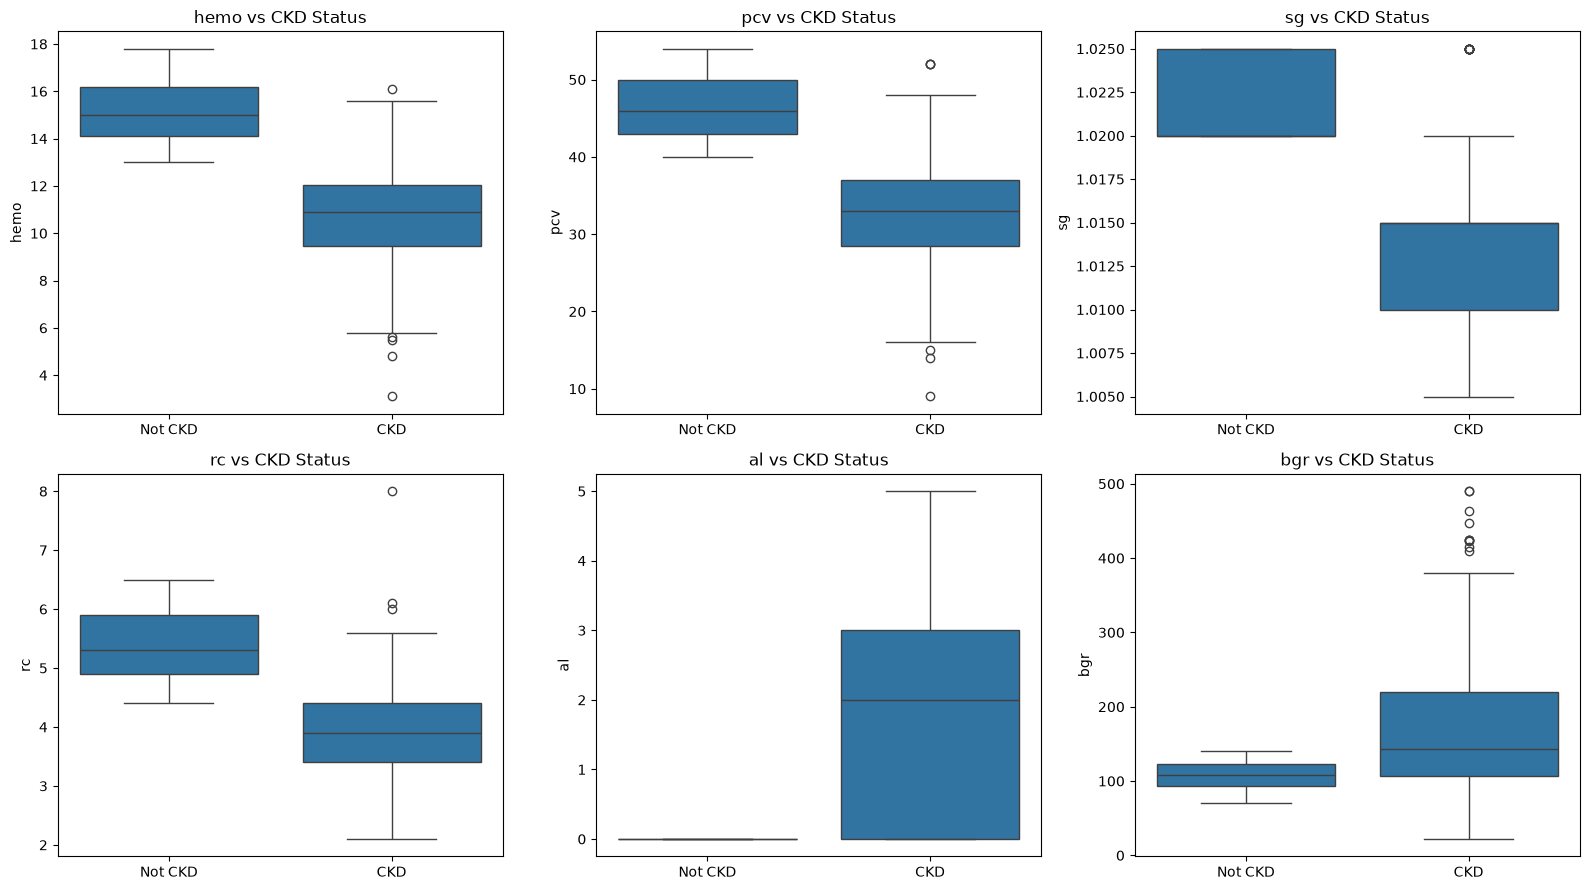

In [17]:
# =============================================================================
# NUMERICAL FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================

print("=" * 70)
print("TOP FEATURES VS CKD STATUS")
print("=" * 70)


fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()


for i, feature in enumerate(top_features):

    sns.boxplot(
        data=df,
        x=target_column,
        y=feature,
        ax=axes[i]
    )

    axes[i].set_xticklabels(["Not CKD", "CKD"])
    axes[i].set_title(f"{feature} vs CKD Status")
    axes[i].set_xlabel("")


plt.tight_layout()
plt.show()

BINARY/CATEGORICAL FEATURES VS CKD STATUS


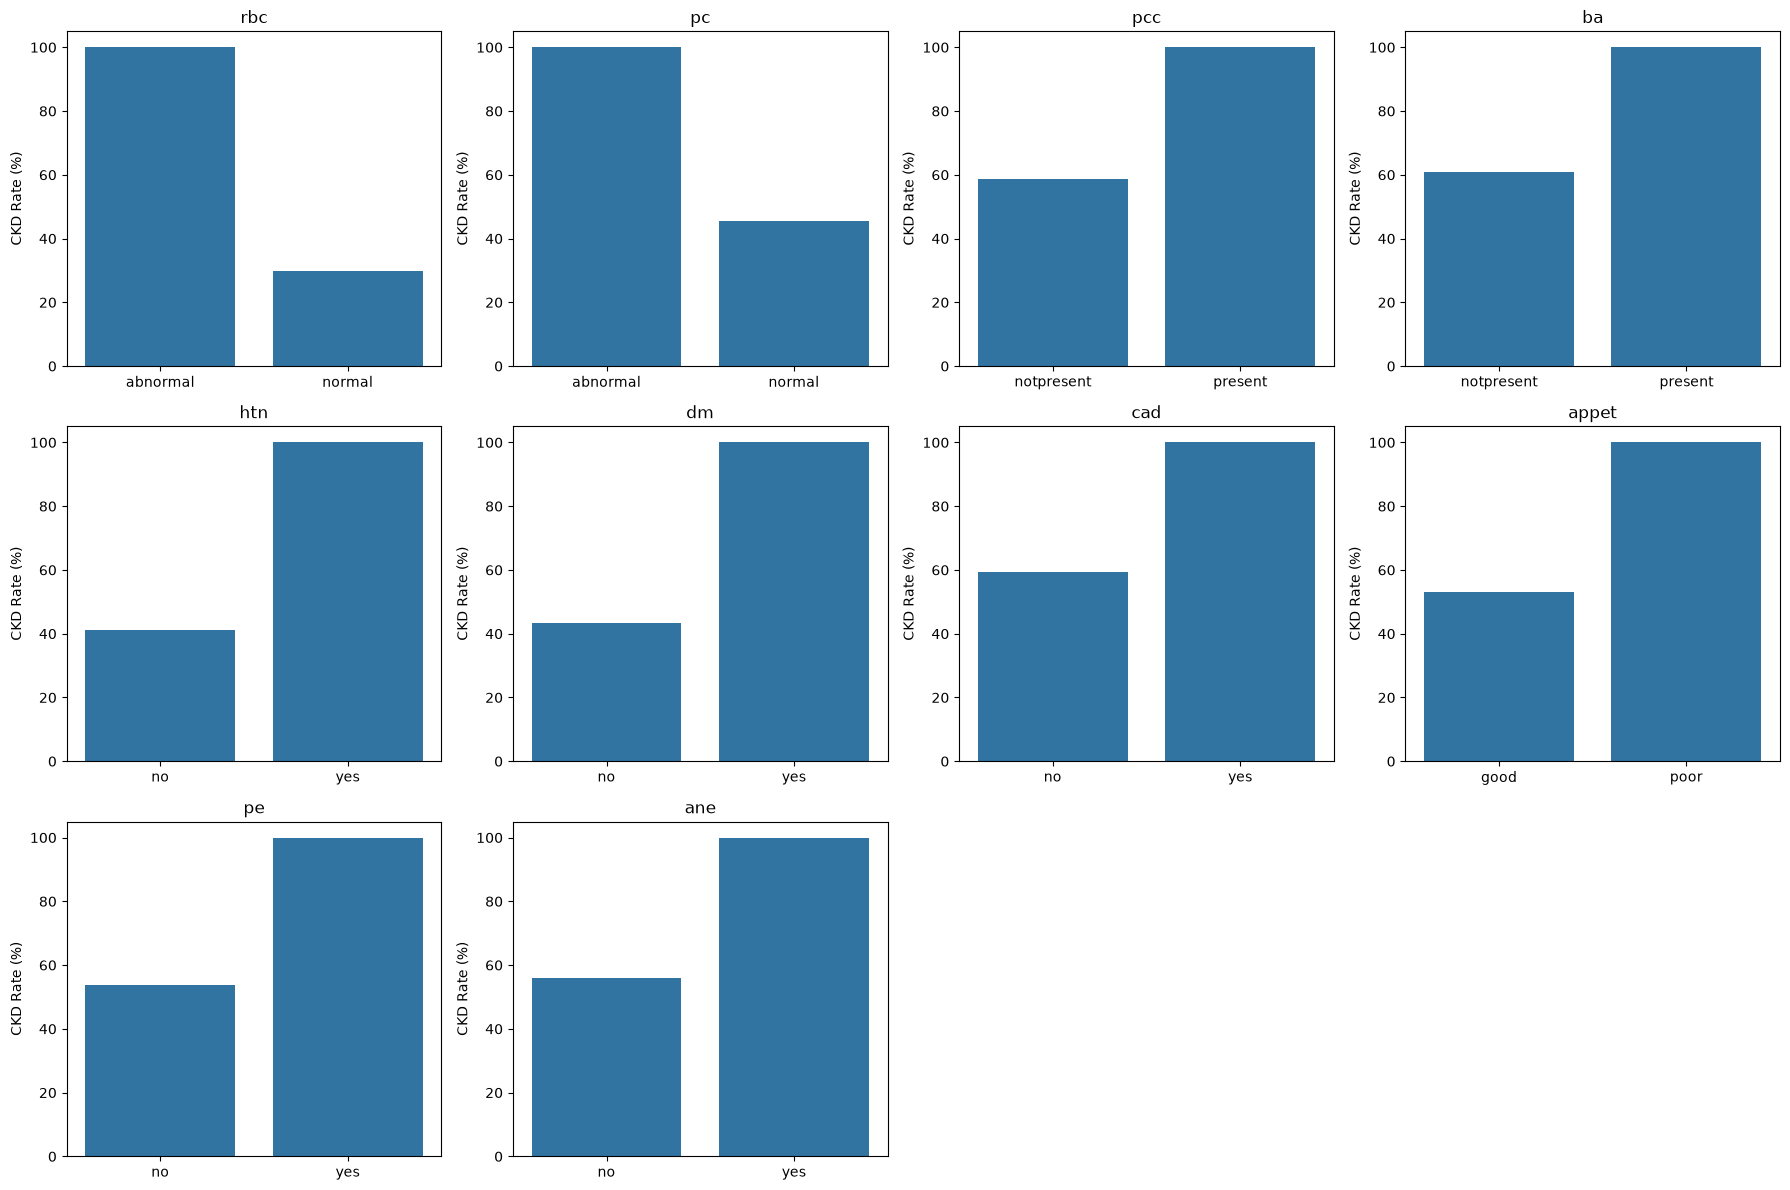

In [18]:
# =============================================================================
# BINARY FEATURES VS TARGET (COMBINED VISUALIZATION)
# =============================================================================


print("=" * 70)
print("BINARY/CATEGORICAL FEATURES VS CKD STATUS")
print("=" * 70)


n_features = len(categorical_features)
cols = 4
rows = (n_features + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    ckd_rate = (
        df.groupby(feature)[target_column]
        .mean() * 100
    )

    sns.barplot(
        x=ckd_rate.index,
        y=ckd_rate.values,
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_ylabel("CKD Rate (%)")
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# STEP 9: EDA SUMMARY
# =============================================================================


print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)


top_pos_corr = (
    correlation_matrix[target_column].drop(target_column).sort_values(ascending=False).head(3)
)
top_neg_corr = (
    correlation_matrix[target_column].drop(target_column).sort_values().head(3)
)
top_outliers = outlier_df.head(3)

eda_summary = pd.DataFrame({
    "EDA Component": [
        "Dataset Size",
        "Features",
        "Missing Values",
        "Duplicate Records",
        "Target Variable",
        "Class Distribution",
        "Highest Positive Correlation (CKD-associated)",
        "Highest Negative Correlation (protective)",
        "Major Outlier Features"
    ],

    "Findings": [
        f"{df.shape[0]} rows and {df.shape[1]} columns",

        "14 numerical + 10 categorical predictors",

        f"{df.isnull().sum().sum()} missing values detected ({df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100:.1f}% overall - rbc worst at 38%)",

        f"{duplicate_count} duplicate rows removed",

        f"{target_column} (0 = notckd, 1 = ckd)",

        (
            f"CKD: {round((df[target_column].value_counts(normalize=True)[1])*100,2)}%, "
            f"Not CKD: {round((df[target_column].value_counts(normalize=True)[0])*100,2)}%"
        ),

        ", ".join([f"{f} ({v:.3f})" for f, v in top_pos_corr.items()]),

        ", ".join([f"{f} ({v:.3f})" for f, v in top_neg_corr.items()]),

        ", ".join([f"{row.Feature} ({getattr(row, '_5')}%)" for row in top_outliers.itertuples()])
    ]
})

display(eda_summary)

EXPLORATORY DATA ANALYSIS SUMMARY


,EDA Component,Findings
0,Dataset Size,400 rows and 26 columns
1,Features,14 numerical + 10 categorical predictors
2,Missing Values,1012 missing values detected (9.7% overall - r...
3,Duplicate Records,0 duplicate rows removed
4,Target Variable,"target (0 = notckd, 1 = ckd)"
5,Class Distribution,"CKD: 62.5%, Not CKD: 37.5%"
6,Highest Positive Correlation (CKD-associated),"al (0.627), bgr (0.420), bu (0.381)"
7,Highest Negative Correlation (protective),"hemo (-0.769), pcv (-0.741), sg (-0.732)"
8,Major Outlier Features,"su (17.38%), sc (13.32%), bu (9.97%)"


In [20]:
# =============================================================================
# STEP 10: SAVE CLEANED DATASET
# =============================================================================


df_clean.to_csv(
    "../../data/processed/ckd_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully")

print("\nSaved File:")
print("data/processed/ckd_cleaned.csv")

print("\nDataset Shape:")
print(df_clean.shape)

print("\nNote: \'cleaned\' here refers to structural cleaning, dtype-correction and duplicate-checking —")
print("it still contains missing values (10% overall). Imputation is a")
print("modeling-stage decision, made explicitly in 02_ckd_doda.ipynb and")

print("\nNext step: 02_ckd_doda.ipynb picks up from here — imputation,")
print("feature selection, the DODA clinical re-weighting layer, and model")
print("evaluation, using the shared functions in src/doda.py.")

Cleaned dataset saved successfully

Saved File:
data/processed/ckd_cleaned.csv

Dataset Shape:
(400, 26)

Note: 'cleaned' here refers to structural cleaning, dtype-correction and duplicate-checking —
it still contains missing values (10% overall). Imputation is a
modeling-stage decision, made explicitly in 02_ckd_doda.ipynb and

Next step: 02_ckd_doda.ipynb picks up from here — imputation,
feature selection, the DODA clinical re-weighting layer, and model
evaluation, using the shared functions in src/doda.py.
